### Loading the Data

In [15]:
import pandas as pd
df = pd.read_excel(r"C:\z_Learn\miraj_pandas\Ml_Project\Data\Main_OnlineKhabar_New.xlsx")
df.head()

,Category,Content
0,Politics,"Kathmandu, January 9 President Ramchandra Paud..."
1,Politics,"Kathmandu, January 9 Legal hurdles have been c..."
2,Politics,"Kathmandu, December 8 The Nepal Army is prepar..."
3,Politics,"Kathmandu, January 8 The Election Commission h..."
4,Politics,"Kathmandu, January 8 Minister for Energy, Wate..."


### Suffle the Data

In [16]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [17]:
df.tail()

,Category,Content
12385,Sports,When Sharmila Roka Magar left Bhairahawa to ce...
12386,Politics,"New York, April 21 Deputy Prime Minister and M..."
12387,Economy,"Kathmandu, November 11 The price of gold has d..."
12388,Politics,"Gandaki, May 5 Chief Minister ofGandaki Provin..."
12389,Economy,"Kathmandu, February 19 Airline companies of Ne..."


In [18]:
df.shape

(12390, 2)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12390 entries, 0 to 12389
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  12390 non-null  object
 1   Content   12386 non-null  object
dtypes: object(2)
memory usage: 193.7+ KB


In [20]:
df.isnull().sum()

Category    0
Content     4
dtype: int64

In [21]:
df.dropna(inplace=True)

In [22]:
df.duplicated().sum()

np.int64(0)

### EDA - Class Distribution


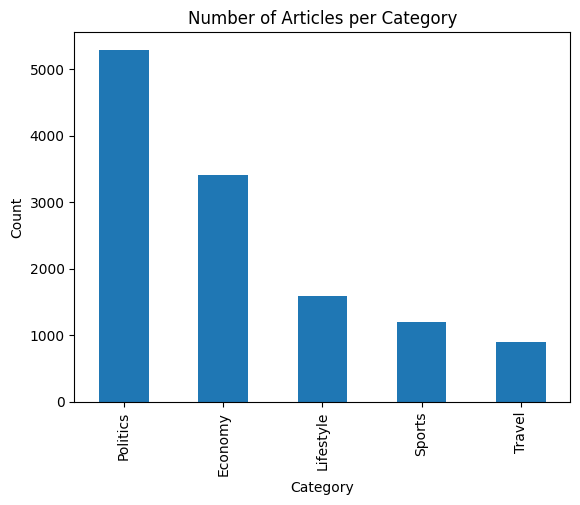

In [25]:
import matplotlib.pyplot as plt

df["Category"].value_counts().plot(kind="bar")
plt.title("Number of Articles per Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

In [33]:
df['Category'].value_counts()

Category
Politics     5291
Economy      3410
Lifestyle    1594
Sports       1195
Travel        896
Name: count, dtype: int64

### EDA - Word Cloud (Overall)


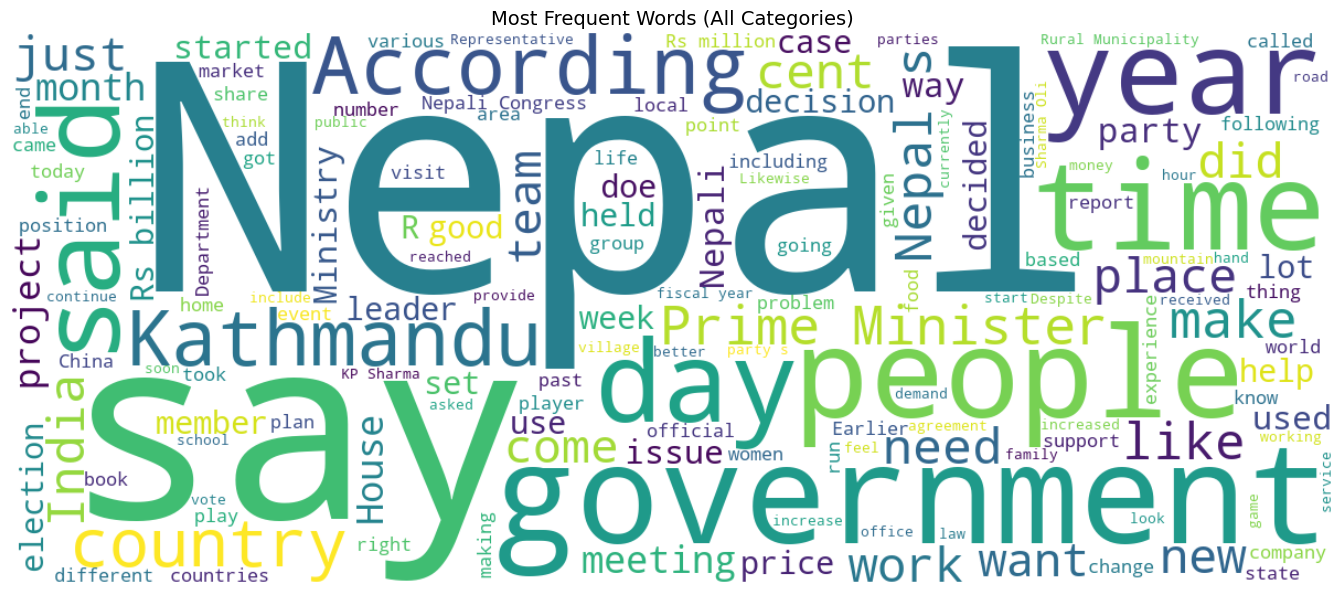

In [29]:
from wordcloud import WordCloud
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

stopwords = set(ENGLISH_STOP_WORDS)

all_text = ' '.join(df['Content'].tolist())
wc = WordCloud(width=1200, height=500, background_color='white',
               stopwords=stopwords, max_words=150,
               colormap='viridis').generate(all_text)

plt.figure(figsize=(14, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words (All Categories)', fontsize=14)
plt.tight_layout()
plt.show()

### EDA - Word Cloud per Category


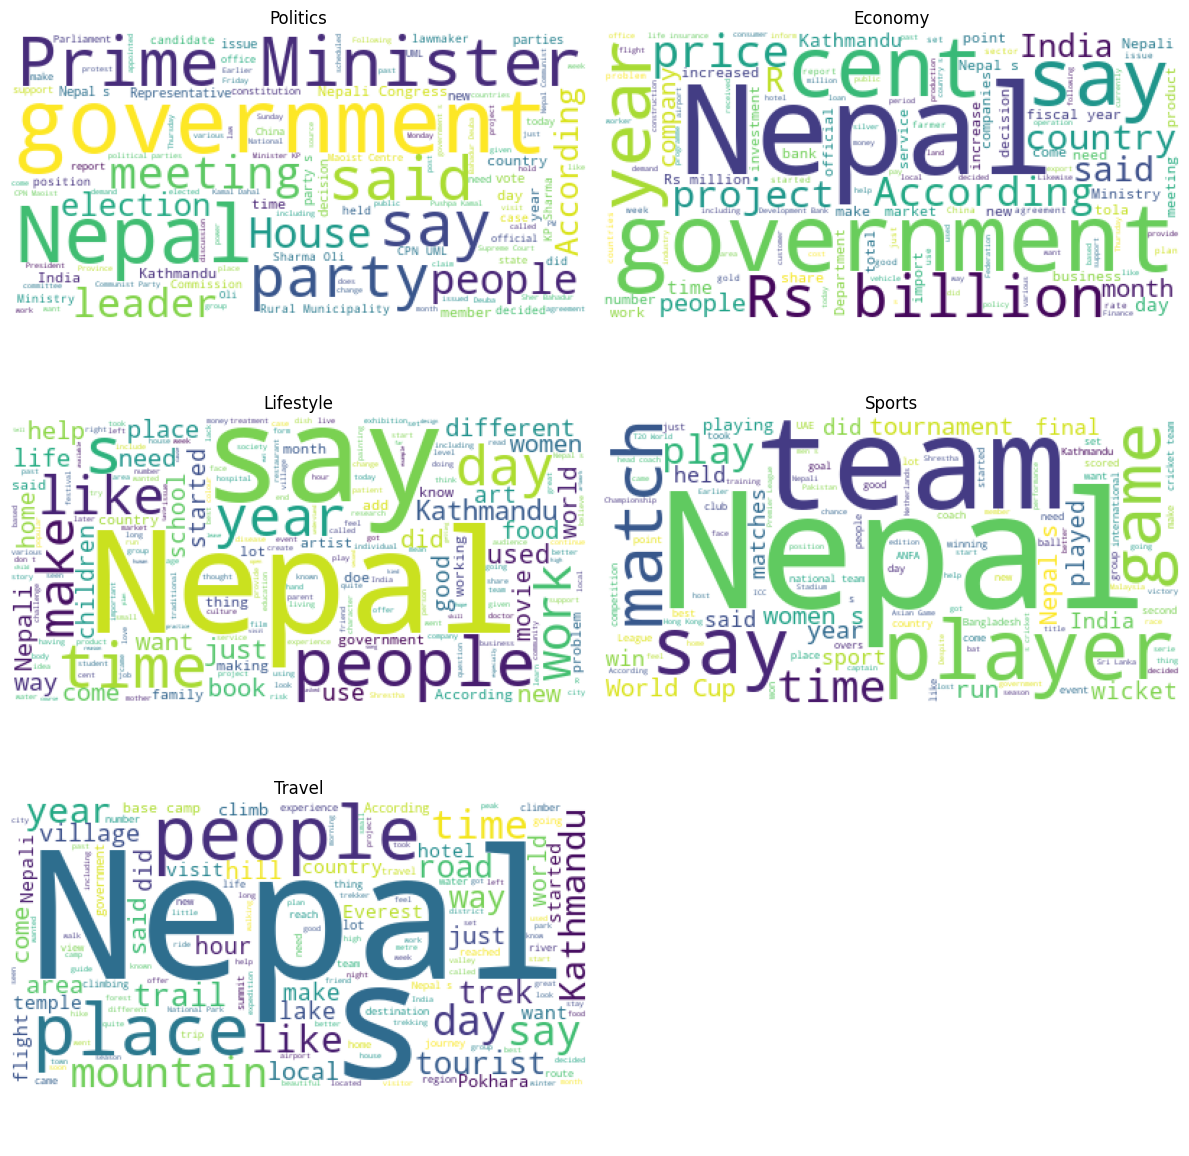

In [34]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

# Politics
text = " ".join(df[df["Category"] == "Politics"]["Content"])
wc = WordCloud(background_color="white", stopwords=stopwords).generate(text)
axes[0].imshow(wc)
axes[0].set_title("Politics")
axes[0].axis("off")

# Economy
text = " ".join(df[df["Category"] == "Economy"]["Content"])
wc = WordCloud(background_color="white", stopwords=stopwords).generate(text)
axes[1].imshow(wc)
axes[1].set_title("Economy")
axes[1].axis("off")

# Lifestyle
text = " ".join(df[df["Category"] == "Lifestyle"]["Content"])
wc = WordCloud(background_color="white", stopwords=stopwords).generate(text)
axes[2].imshow(wc)
axes[2].set_title("Lifestyle")
axes[2].axis("off")

# Sports
text = " ".join(df[df["Category"] == "Sports"]["Content"])
wc = WordCloud(background_color="white", stopwords=stopwords).generate(text)
axes[3].imshow(wc)
axes[3].set_title("Sports")
axes[3].axis("off")

# Travel
text = " ".join(df[df["Category"] == "Travel"]["Content"])
wc = WordCloud(background_color="white", stopwords=stopwords).generate(text)
axes[4].imshow(wc)
axes[4].set_title("Travel")
axes[4].axis("off")

# Hide the last empty subplot
axes[5].axis("off")

plt.tight_layout()
plt.show()

### Word Count Distribution Across Categories

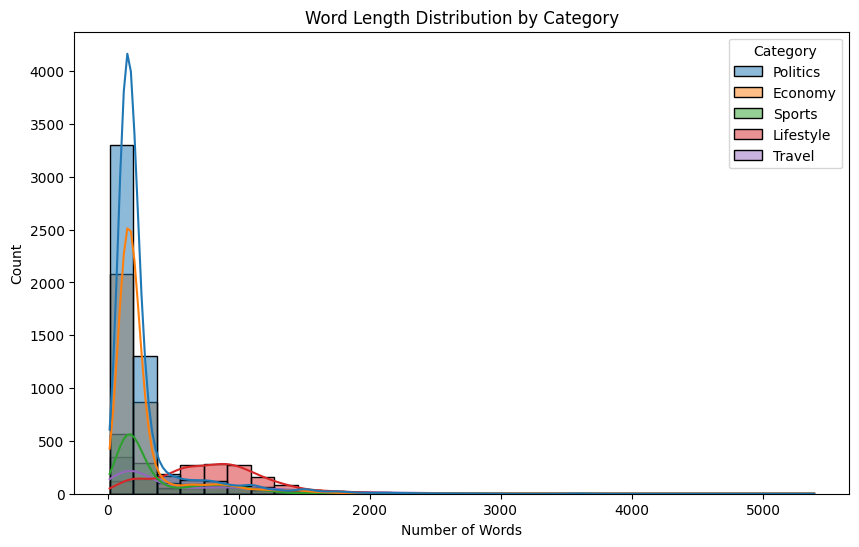

In [ ]:
import seaborn as sns

df["Word_Length"] = df["Content"].str.split().str.len()

plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="Word_Length",
    hue="Category",
    bins=30,
    kde=True
)

plt.title("Word Length Distribution by Category")
plt.xlabel("Number of Words")
plt.ylabel("Count")
plt.show()

### Text Cleaning (NLP Pipeline)

In [49]:
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()
word = "running"
stemmer.stem(word)


'run'

In [52]:
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()

def preprocess_text(text):
    # Lowercase
    text = text.lower()

    # Remove punctuation and special characters
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    # Split into words
    words = text.split()

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    # Stemming
    words = [stemmer.stem(word) for word in words]

    return " ".join(words)

In [53]:
df["Cleaned_Content"] = df["Content"].apply(preprocess_text)


In [54]:
df.head()

,Category,Content,Word_Length,Cleaned_Content
0,Politics,"Kathmandu, June 7 The voters’ list for the upc...",188,kathmandu june voter list upcom provinci feder...
1,Economy,"Kathmandu, December 5 Student organisations cl...",154,kathmandu decemb student organis close rule co...
2,Economy,"Recently,digital marketingis gaining a lot of ...",1490,recentlydigit marketingi gain lot popular nepa...
3,Economy,Public finance management (PFM) is the way cer...,808,public financ manag pfm way certain law system...
4,Politics,"Patan, January 25 Chairperson of Ujyalo Nepal ...",194,patan januari chairperson ujyalo nepal parti k...


### Train / Test Split 


In [55]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df['Category'])
X = df['Cleaned_Content'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print('Train size :', X_train.shape[0])
print('Test  size :', X_test.shape[0])
print('Classes    :', list(le.classes_))

Train size : 9908
Test  size : 2478
Classes    : ['Economy', 'Lifestyle', 'Politics', 'Sports', 'Travel']


### Feature Extraction - CountVectorizer


In [56]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec  = vectorizer.transform(X_test)

print('Train matrix shape :', X_train_vec.shape)
print('Test  matrix shape :', X_test_vec.shape)
print('Vocabulary size    :', len(vectorizer.vocabulary_))

Train matrix shape : (9908, 5000)
Test  matrix shape : (2478, 5000)
Vocabulary size    : 5000


### Model Training - Multinomial Naive Bayes


In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

model = MultinomialNB()
model.fit(X_train_vec, y_train)
y_pred = model.predict(X_test_vec)

accuracy = accuracy_score(y_test, y_pred)
print(f'Test accuracy : {accuracy:.4f}')

Test accuracy : 0.8886


### Model Evaluation - Multinomial Naive Bayes


Classification report:

              precision    recall  f1-score   support

     Economy       0.84      0.86      0.85       682
   Lifestyle       0.86      0.86      0.86       319
    Politics       0.94      0.93      0.94      1059
      Sports       0.94      0.95      0.94       239
      Travel       0.77      0.74      0.75       179

    accuracy                           0.89      2478
   macro avg       0.87      0.87      0.87      2478
weighted avg       0.89      0.89      0.89      2478



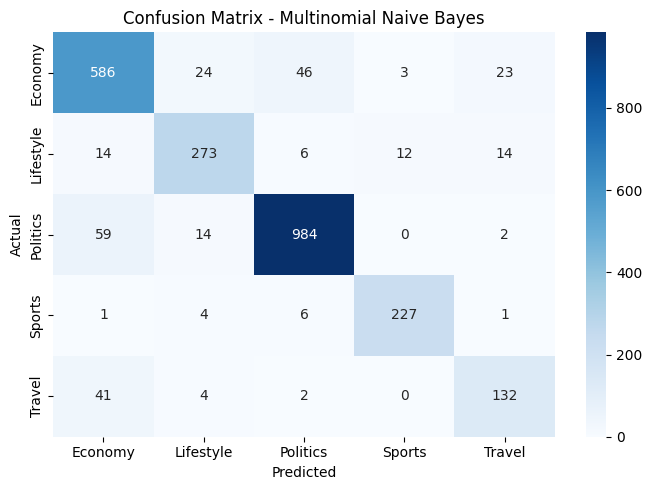

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test_vec)

print('Classification report:\n')
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

### Model Training - Logistics Regression


In [60]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression(max_iter=1000)

model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)

accuracy = accuracy_score(y_test, y_pred)

print(f"Test accuracy : {accuracy:.4f}")

Test accuracy : 0.8931


### Model Evaluation - Logistics Regression

Classification report:

              precision    recall  f1-score   support

     Economy       0.84      0.86      0.85       682
   Lifestyle       0.90      0.82      0.86       319
    Politics       0.93      0.94      0.94      1059
      Sports       0.94      0.96      0.95       239
      Travel       0.78      0.80      0.79       179

    accuracy                           0.89      2478
   macro avg       0.88      0.87      0.88      2478
weighted avg       0.89      0.89      0.89      2478



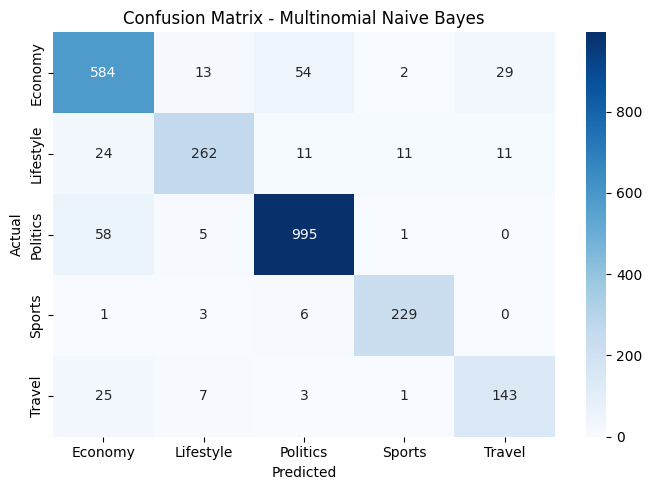

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test_vec)

print('Classification report:\n')
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [68]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

model = DecisionTreeClassifier(
    max_depth=30,
    min_samples_leaf=10,
    random_state=42
)

model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)

accuracy = accuracy_score(y_test, y_pred)

print(f"Test accuracy : {accuracy:.4f}")

Test accuracy : 0.7760


### Model Evaluation - Decision Tree

Classification report:

              precision    recall  f1-score   support

     Economy       0.71      0.73      0.72       682
   Lifestyle       0.67      0.66      0.66       319
    Politics       0.86      0.87      0.86      1059
      Sports       0.86      0.79      0.82       239
      Travel       0.62      0.60      0.61       179

    accuracy                           0.78      2478
   macro avg       0.74      0.73      0.74      2478
weighted avg       0.78      0.78      0.78      2478



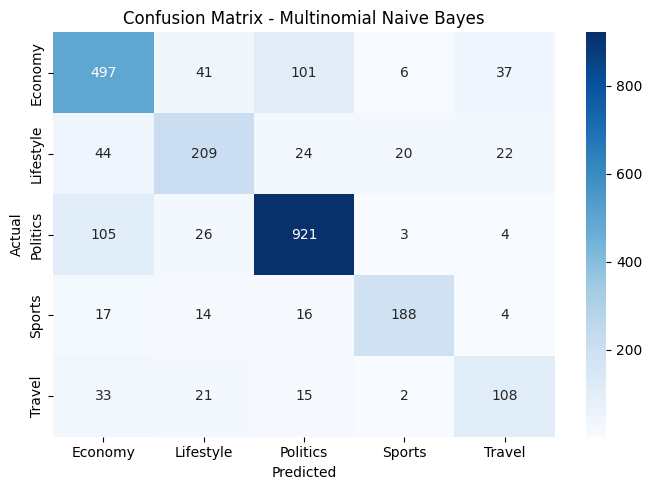

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test_vec)

print('Classification report:\n')
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

### Model Training - Random Forest

In [70]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=50,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)

accuracy = accuracy_score(y_test, y_pred)

print(f"Test accuracy : {accuracy:.4f}")

Test accuracy : 0.8672


### Model Evaluation - Random Forest

Classification report:

              precision    recall  f1-score   support

     Economy       0.82      0.83      0.83       682
   Lifestyle       0.81      0.82      0.82       319
    Politics       0.90      0.95      0.92      1059
      Sports       0.93      0.92      0.93       239
      Travel       0.87      0.48      0.62       179

    accuracy                           0.87      2478
   macro avg       0.87      0.80      0.82      2478
weighted avg       0.87      0.87      0.86      2478



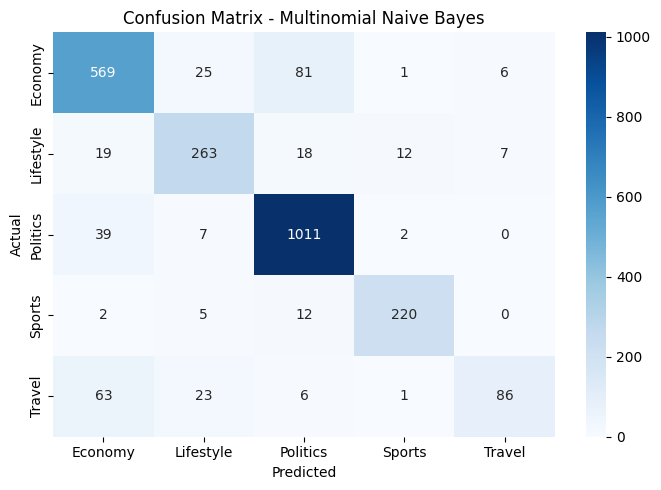

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test_vec)

print('Classification report:\n')
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

### Model Training - KNN

In [74]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

model = KNeighborsClassifier(
    n_neighbors=7,
    weights="distance",
    metric="cosine"
)

model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)

accuracy = accuracy_score(y_test, y_pred)

print(f"Test accuracy : {accuracy:.4f}")

Test accuracy : 0.8874


### Model Evaluation - KNN

Classification report:

              precision    recall  f1-score   support

     Economy       0.87      0.84      0.86       682
   Lifestyle       0.85      0.83      0.84       319
    Politics       0.93      0.94      0.93      1059
      Sports       0.94      0.94      0.94       239
      Travel       0.72      0.80      0.76       179

    accuracy                           0.89      2478
   macro avg       0.86      0.87      0.86      2478
weighted avg       0.89      0.89      0.89      2478



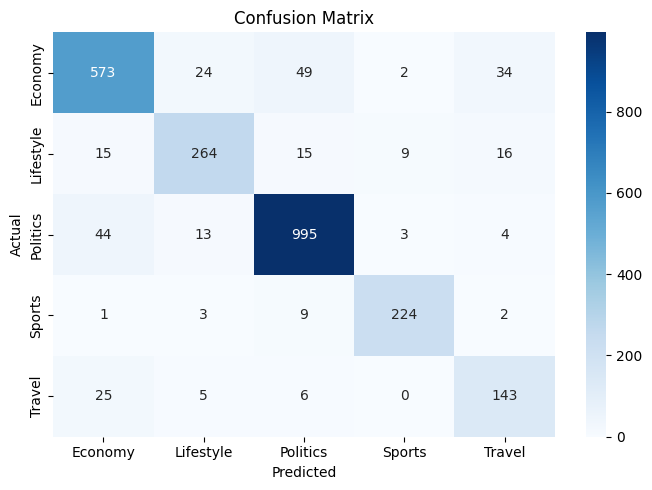

In [77]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test_vec)

print('Classification report:\n')
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

`From the observation, Naive Bayes, Logistic Regression, and KNN are performing well on the data, so I would choose KNN as the final model`

### Lets Choose the Best Parameters For the Knn that gives me the best Score 

In [78]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier()

param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11],
    "weights": ["uniform", "distance"],
    "metric": ["cosine", "euclidean"]
}

grid = GridSearchCV(
    knn,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train_vec, y_train)

print("Best Parameters:", grid.best_params_)

best_knn = grid.best_estimator_

y_pred = best_knn.predict(X_test_vec)

accuracy = accuracy_score(y_test, y_pred)

print(f"Test accuracy : {accuracy:.4f}")

Best Parameters: {'metric': 'cosine', 'n_neighbors': 9, 'weights': 'distance'}
Test accuracy : 0.8858


### 5-Fold Cross-Validation (cv=5)

`cv=5` means **5-fold cross-validation**.

The training data is divided into 5 parts:


Fold 1 | Fold 2 | Fold 3 | Fold 4 | Fold 5


The model trains and tests 5 times:

Train on folds 2,3,4,5 → Test on fold 1<br>
Train on folds 1,3,4,5 → Test on fold 2<br>
Train on folds 1,2,4,5 → Test on fold 3<br>
Train on folds 1,2,3,5 → Test on fold 4<br>
Train on folds 1,2,3,4 → Test on fold 5<br>


After all runs, it calculates the average accuracy.

Example:
Fold accuracies:

0.86 <br>
0.88 <br>
0.90 <br>
0.87 <br>
0.89 <br>

(0.86 + 0.88 + 0.90 + 0.87 + 0.89) / 5 = 0.88

Based on the greater average score we select the best model parameters.

### Retraining Our Model On the Best Params

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
knn_final = KNeighborsClassifier(metric='cosine', n_neighbors=9, weights='distance')
knn_final.fit(X_train_vec, y_train)
y_pred = knn_final.predict(X_test_vec)
accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy : {accuracy:.4f}")

Test accuracy : 0.8858


### Save Artifacts

In [80]:
import os
from sklearn.pipeline import Pipeline
import joblib
import json

ModelFolder = os.path.join(os.getcwd(), "Models")
if not os.path.exists(ModelFolder):
    os.mkdir(ModelFolder)  # Create the Models folder if it doesn't exist
    
pipeline = Pipeline([
    ('vectorizer', vectorizer),
    ('classifier', knn_final)
])

joblib.dump(pipeline, os.path.join(ModelFolder, "knn_model.pkl"))
joblib.dump(le, os.path.join(ModelFolder, "label_encoder.pkl"))

metadata = {
    "model_name": "K-Nearest Neighbors Classifier",
    "vectorizer": "CountVectorizer",
    'vectorizer_params' : vectorizer.get_params(),
    "n_neighbors": 9,
    "weights": "distance",
    "metric": "cosine",
    "train_size": X_train.shape[0],
    "test_size": X_test.shape[0],
    "classes": list(le.classes_),
    "accuracy": accuracy,
    'preprocessing'     : 'resuse preprocess_text function for preprocessing the text data',
}

with open(os.path.join(ModelFolder, 'metadata.json'), 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, default=str)
